In [40]:
import pandas as pd

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [41]:
import numpy as np

area = np.array(df['area'])
price = np.array(df['price'])
print("Area: ",area[:10])
print("Price: ", price[:10])

Area:  [ 7420  8960  9960  7500  7420  7500  8580 16200  8100  5750]
Price:  [13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000]


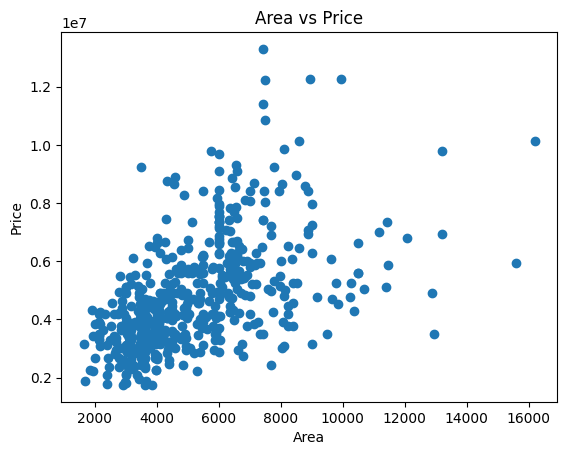

In [42]:
import matplotlib.pyplot as plt

plt.scatter(area,price)
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [43]:
def make_prediction(x,y,w,b):
    m = x.shape[0]
    
    prediction_list = np.zeros(m,);
    for i in range(m):
        prediction_list[i] = w*x[i] + b;
        
    return prediction_list;

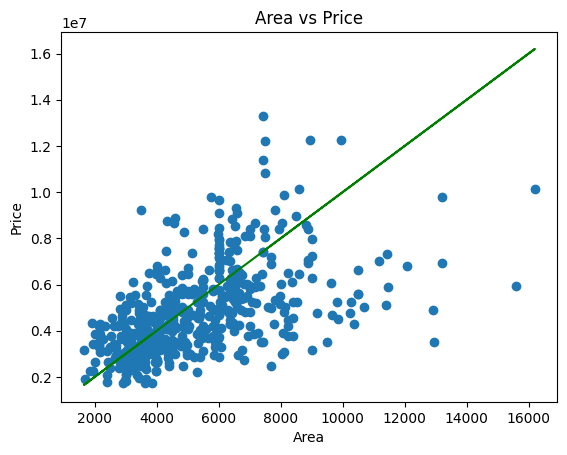

In [44]:
prediction_list = make_prediction(area,price,w=1000,b=2000);

plt.scatter(area,price)
plt.plot(area,prediction_list,color='green')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

Cost - Mean Squared Error

In [45]:
def compute_cost(x,y,w,b):
    m = x.shape[0];
    
    cost = 0.0;
    
    for i in range(m):
        prediction = w * x[i] + b;
        error = prediction - y[i];
        error_squared = error ** 2;
        cost = cost + error_squared;
    
    cost = cost/(2*m);
    
    return cost;

In [46]:
print(f"w = 1000, b = 2000: {compute_cost(area,price,w=1000,b=2000)}")
print(f"w = 600, b = 1500: {compute_cost(area,price,w=600,b=1500)}")
print(f"w = 300, b = 1000: {compute_cost(area,price,w=300,b=1000)}")
print(f"w = 70, b = 50: {compute_cost(area,price,w=20,b=10)}")

w = 1000, b = 2000: 1999239075338.165
w = 600, b = 1500: 2691861182099.633
w = 300, b = 1000: 6492121865072.11
w = 70, b = 50: 12578657115777.89


Gradient Descent

In [47]:
def calculate_gradient(x,y,w,b):
    m = x.shape[0];
    
    dj_dw = 0.0;
    dj_db = 0.0;
    
    for i in range(m):
        prediction = w * x[i] + b;
        error = prediction -  y[i];
        dj_dw = dj_dw + (error * x[i]);
        dj_db = dj_db + error;
    
    dj_dw = dj_dw/m;
    dj_db = dj_db/m;
    
    return dj_dw, dj_db;

In [48]:
print(calculate_gradient(area,price,w=500,b=600))

(np.float64(-11105356588.623854), np.float64(-2190858.6055045873))


In [49]:
def gredient_descent(x,y,w_init,b_init,max_iter,alpha):
    w = w_init;
    b = b_init;
    
    cost_memo = [];
    iteration = [];
    
    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(x,y,w,b);
        
        w = w - (alpha*dj_dw);
        b = b - (alpha*dj_db);
        
        cost = compute_cost(x,y,w,b);
        
        cost_memo.append(cost);
        iteration.append(i);
        
        if(i%100 == 0):
            print(f"iteration {i}: w={w:0.3f},b={b:0.3f}, cost={cost:0.3f}")
    
    return w,b,cost_memo,iteration;

In [55]:
w_final, b_final, cost_memo, iteration = gredient_descent(area,price,0.0,0.0,10000,0.000000000001)
print(f"W_Final = {w_final}")
print(f"B_Final = {b_final}")

iteration 0: w=0.027,b=0.000, cost=13106202261331.059
iteration 100: w=2.695,b=0.000, cost=13035016698499.561
iteration 200: w=5.355,b=0.001, cost=12964274367018.637
iteration 300: w=8.006,b=0.001, cost=12893972507142.889
iteration 400: w=10.649,b=0.002, cost=12824108376310.215
iteration 500: w=13.284,b=0.002, cost=12754679249034.875
iteration 600: w=15.911,b=0.003, cost=12685682416801.246
iteration 700: w=18.529,b=0.003, cost=12617115187957.953
iteration 800: w=21.140,b=0.004, cost=12548974887613.010
iteration 900: w=23.742,b=0.004, cost=12481258857529.453
iteration 1000: w=26.336,b=0.005, cost=12413964456021.639
iteration 1100: w=28.922,b=0.005, cost=12347089057852.088
iteration 1200: w=31.500,b=0.006, cost=12280630054129.303
iteration 1300: w=34.070,b=0.006, cost=12214584852205.689
iteration 1400: w=36.632,b=0.007, cost=12148950875576.682
iteration 1500: w=39.186,b=0.007, cost=12083725563780.104
iteration 1600: w=41.732,b=0.007, cost=12018906372296.186
iteration 1700: w=44.270,b=0.0

Text(0, 0.5, 'Cost')

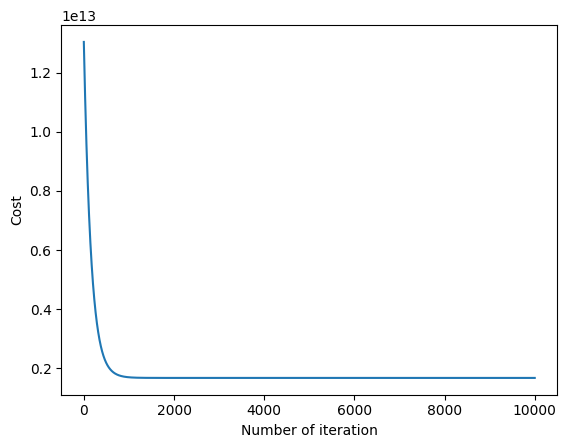

In [53]:
plt.plot(iteration,cost_memo)
plt.xlabel("Number of iteration")
plt.ylabel("Cost")